# Locally Weighted Linear Regression (LWLR)

## Overview

Locally Weighted Linear Regression (LWLR), also known as **locally estimated scatterplot smoothing** or **LOESS**, is a non-parametric regression technique that fits local linear models to regions of the feature space. Rather than fitting a single global model, LWLR gives more weight to nearby training examples when making predictions.

### When to Use LWLR:
- **Non-linear relationships**: When the relationship between variables is non-linear but smooth
- **Unknown functional form**: When you don't know the underlying relationship
- **Exploratory analysis**: For data exploration and visualization
- **Robustness**: Need robustness to outliers (weighted approach)
- **Small to medium datasets**: LWLR has O(n) prediction time

### Problem Formulation

Given a query point $x^*$, we want to predict $y^*$ by:
1. Assigning weights $w_i$ to all training examples based on their distance to $x^*$
2. Fitting a weighted linear regression model using these weights
3. Predicting using this local model

**Data Representation:**

**Form 1: Single Sample/Equation**

For a query point $x^*$, we compute weights for each training example based on distance:
$$w_i = \exp\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$$

where $\tau$ is the bandwidth parameter and $x^{(i)}$ is the $i$-th training example.

**Form 2: Vector/Summation**

The weighted loss function over all training samples:
$$J(\theta) = \sum_{i=1}^{n} w_i \left(y^{(i)} - \theta^T x^{(i)}\right)^2$$

**Form 3: Matrix Form**

Using matrix notation with $W = \text{diag}(w_1, w_2, \ldots, w_n)$:
$$J(\theta) = (y - X\theta)^T W (y - X\theta)$$

### Concrete Example

Consider predicting house prices with 3 training samples:

| Sample | Size (sq ft) | Price ($) |
|--------|-------------|----------|
| 1 | 1000 | 150000 |
| 2 | 1500 | 225000 |
| 3 | 2000 | 300000 |

For query $x^* = 1200$ sq ft with bandwidth $\tau = 300$:
- $w_1 = \exp(-(1000-1200)^2/(2 \cdot 300^2)) = 0.917$
- $w_2 = \exp(-(1500-1200)^2/(2 \cdot 300^2)) = 0.268$
- $w_3 = \exp(-(2000-1200)^2/(2 \cdot 300^2)) = 0.004$

Sample 1 gets highest weight (nearest), so influences the prediction most.

## Learning Objectives
By the end of this notebook, you will be able to:
1. **Explain** why LWLR is non-parametric: a new weighted least squares problem $\theta^* = (X^TWX)^{-1}X^TWy$ is solved per query point rather than once globally.
2. **Compute** the Gaussian kernel weights $w_i = \exp\!\left(-\frac{\|x^{(i)}-x^*\|^2}{2\tau^2}\right)$ and describe how $\tau$ controls the locality.
3. **Implement** LWLR from scratch in NumPy and make predictions for new query points.
4. **Diagnose** underfitting (large $\tau$) vs overfitting (small $\tau$) from the bias-variance perspective.
5. **Select** bandwidth $\tau$ via cross-validation on a held-out validation set.
6. **Contrast** LWLR's $O(n^2)$ prediction cost against global linear regression's $O(1)$ cost, and explain the memory trade-off.

> **Prerequisite**: Normal Equation ([ml_001_04](ml_001_04_normal_equation.ipynb)), kernel functions.

## Section 1: Mathematical Foundations

### Core Components

#### 1.1 Weight Function (Kernel)

The weight function determines how much influence each training example has on the prediction. Common choices:

**Gaussian Kernel** (most common):
$$w_i = \exp\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$$

**Linear Kernel**:
$$w_i = \max\left(0, 1 - \frac{\|x^{(i)} - x^*\|}{\tau}\right)$$

**Epanechnikov Kernel**:
$$w_i = \max\left(0, \left(1 - \left(\frac{\|x^{(i)} - x^*\|}{\tau}\right)^2\right)^2\right)$$

#### 1.2 Bandwidth Parameter ($\tau$)

Controls the "locality" of the regression:
- **Small $\tau$**: Narrow kernel, only nearby points matter, may overfit
- **Large $\tau$**: Wide kernel, distant points contribute more, smoother but biased

#### 1.3 Weighted Least Squares Solution

Given weights $w_i$, the optimal $\theta$ minimizes:
$$J(\theta) = \sum_{i=1}^{n} w_i \left(y^{(i)} - \theta^T x^{(i)}\right)^2$$

Taking the derivative and setting to zero:
$$\frac{\partial J}{\partial \theta} = -2 \sum_{i=1}^{n} w_i x^{(i)} \left(y^{(i)} - \theta^T x^{(i)}\right) = 0$$

Rearranging:
$$\sum_{i=1}^{n} w_i x^{(i)} y^{(i)} = \theta^T \sum_{i=1}^{n} w_i x^{(i)} x^{(i)T}$$

In matrix form:
$$\theta = \left(X^T W X\right)^{-1} X^T W y$$

where $W = \text{diag}(w_1, w_2, \ldots, w_n)$.

## Section 2: LWLR Algorithm

### Prediction Algorithm

**Input**: Training set $\{(x^{(1)}, y^{(1)}), \ldots, (x^{(n)}, y^{(n)})\}$, query point $x^*$, bandwidth $\tau$

**Output**: Predicted value $\hat{y}^*$

**Algorithm**:
1. For each training example $i = 1, \ldots, n$:
   - Compute distance: $d_i = \|x^{(i)} - x^*\|$
   - Compute weight: $w_i = \text{kernel}(d_i, \tau)$
2. Form weight matrix: $W = \text{diag}(w_1, \ldots, w_n)$
3. Solve weighted least squares: $\theta^* = (X^T W X)^{-1} X^T W y$
4. Predict: $\hat{y}^* = (\theta^*)^T x^*$

### Key Observations

1. **For each query point**, we solve a new regression problem
   - Non-parametric: different model for each prediction
   - More flexible than global linear regression

2. **Computational cost**:
   - Training is O(1): just store the data
   - Prediction is O(n²) for $m$ query points: need to solve $m$ weighted least squares problems

3. **Memory requirements**:
   - Must store all training data (lazy learning)
   - No model parameters to learn

4. **No explicit model**:
   - Can't write down $f(x) = \theta^T x$ globally
   - Predictions depend on stored training data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import time

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 3: Implementation from Scratch

Let's implement LWLR from scratch using NumPy.

In [2]:
def gaussian_kernel(distance, tau):
    """
    Gaussian kernel for LWLR.
    
    Args:
        distance: Distance or array of distances
        tau: Bandwidth parameter
    
    Returns:
        Weight value(s) between 0 and 1
    """
    return np.exp(-distance**2 / (2 * tau**2))

def linear_kernel(distance, tau):
    """
    Linear kernel for LWLR.
    """
    return np.maximum(0, 1 - distance / tau)

def epanechnikov_kernel(distance, tau):
    """
    Epanechnikov kernel for LWLR.
    """
    r = distance / tau
    return np.maximum(0, (1 - r**2)**2)

class LocallyWeightedLinearRegression:
    """
    Locally Weighted Linear Regression (LWLR) implementation.
    """
    
    def __init__(self, tau=0.1, kernel='gaussian'):
        """
        Initialize LWLR model.
        
        Args:
            tau: Bandwidth parameter
            kernel: 'gaussian', 'linear', or 'epanechnikov'
        """
        self.tau = tau
        self.kernel_name = kernel
        
        if kernel == 'gaussian':
            self.kernel = gaussian_kernel
        elif kernel == 'linear':
            self.kernel = linear_kernel
        elif kernel == 'epanechnikov':
            self.kernel = epanechnikov_kernel
        else:
            raise ValueError(f"Unknown kernel: {kernel}")
        
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        """
        Store training data (lazy learning - no actual training).
        
        Args:
            X: Training features (n_samples, n_features)
            y: Training targets (n_samples,)
        """
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
    
    def predict_single(self, x_query):
        """
        Predict for a single query point.
        
        Args:
            x_query: Single query point (n_features,)
        
        Returns:
            Predicted value
        """
        # Ensure x_query is 1D or reshape appropriately
        x_query = np.asarray(x_query)
        if x_query.ndim == 0:
            x_query = x_query.reshape(1)
        
        # Compute distances from query point to all training points
        distances = np.linalg.norm(self.X_train - x_query, axis=1)
        
        # Compute weights using kernel
        weights = self.kernel(distances, self.tau)
        
        # Ensure minimum numerical stability
        if weights.sum() < 1e-10:
            weights = np.ones_like(weights) / len(weights)
        
        # Form weight matrix
        W = np.diag(weights)
        
        # Solve weighted least squares: theta = (X^T W X)^{-1} X^T W y
        try:
            XtWX = self.X_train.T @ W @ self.X_train
            XtWy = self.X_train.T @ W @ self.y_train
            theta = np.linalg.solve(XtWX, XtWy)
        except np.linalg.LinAlgError:
            # If singular, use pseudoinverse
            theta = np.linalg.pinv(self.X_train.T @ W @ self.X_train) @ self.X_train.T @ W @ self.y_train
        
        # Make prediction
        prediction = np.dot(x_query, theta)
        return prediction
    
    def predict(self, X):
        """
        Predict for multiple query points.
        
        Args:
            X: Query points (n_queries, n_features)
        
        Returns:
            Predictions (n_queries,)
        """
        X = np.asarray(X)
        if X.ndim == 1:
            return self.predict_single(X)
        
        predictions = np.array([self.predict_single(x) for x in X])
        return predictions

print("LWLR class defined successfully!")

LWLR class defined successfully!


## Section 4: Example 1 - 1D Non-Linear Data

Let's create a simple 1D non-linear dataset and compare LWLR with linear regression.

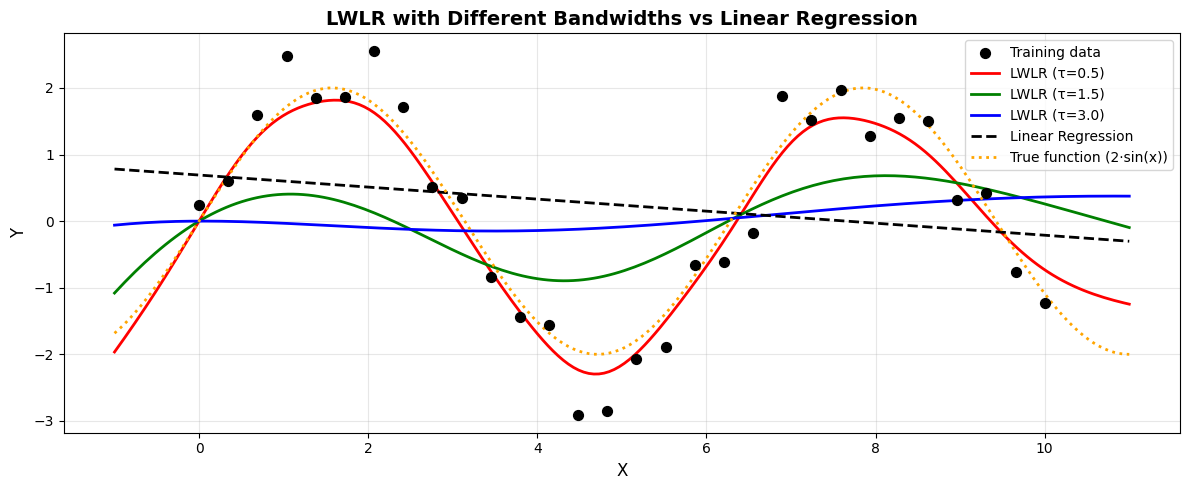

1D LWLR visualization complete!


In [3]:
# Generate 1D non-linear synthetic data
n_samples = 30
X_1d = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_1d = 2 * np.sin(X_1d.ravel()) + np.random.randn(n_samples) * 0.5

# Query points for prediction
X_query_1d = np.linspace(-1, 11, 200).reshape(-1, 1)

# Fit LWLR with different bandwidths
lwlr_small = LocallyWeightedLinearRegression(tau=0.5, kernel='gaussian')
lwlr_small.fit(X_1d, y_1d)
y_pred_small = lwlr_small.predict(X_query_1d)

lwlr_medium = LocallyWeightedLinearRegression(tau=1.5, kernel='gaussian')
lwlr_medium.fit(X_1d, y_1d)
y_pred_medium = lwlr_medium.predict(X_query_1d)

lwlr_large = LocallyWeightedLinearRegression(tau=3.0, kernel='gaussian')
lwlr_large.fit(X_1d, y_1d)
y_pred_large = lwlr_large.predict(X_query_1d)

# Linear regression for comparison
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(X_1d.ravel(), y_1d, 1)
y_pred_linear = np.polyval(coeffs, X_query_1d.ravel())

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

# Scatter plot of data
ax.scatter(X_1d, y_1d, color='black', s=50, label='Training data', zorder=3)

# LWLR predictions
ax.plot(X_query_1d, y_pred_small, 'r-', linewidth=2, label='LWLR (τ=0.5)')
ax.plot(X_query_1d, y_pred_medium, 'g-', linewidth=2, label='LWLR (τ=1.5)')
ax.plot(X_query_1d, y_pred_large, 'b-', linewidth=2, label='LWLR (τ=3.0)')
ax.plot(X_query_1d, y_pred_linear, 'k--', linewidth=2, label='Linear Regression')

# True underlying function
y_true = 2 * np.sin(X_query_1d.ravel())
ax.plot(X_query_1d, y_true, 'orange', linewidth=2, linestyle=':', label='True function (2·sin(x))')

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('LWLR with Different Bandwidths vs Linear Regression', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("1D LWLR visualization complete!")

## Section 5: Bandwidth Selection

The bandwidth parameter $\tau$ is crucial for LWLR performance. Let's analyze its effect systematically.

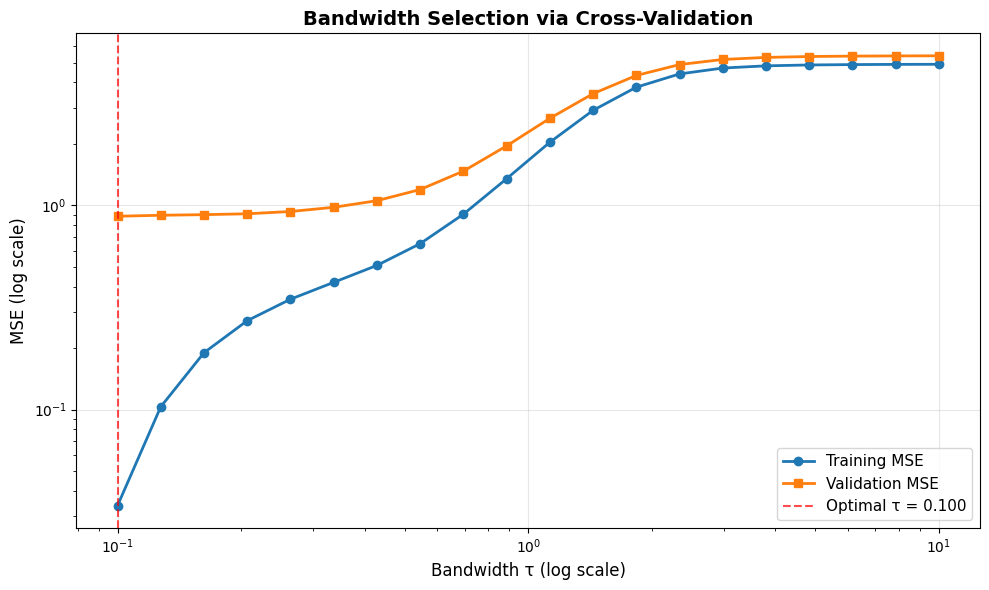


Optimal bandwidth: τ = 0.100
Validation MSE at optimal τ: 0.8847


In [4]:
# Create a training/validation split
np.random.seed(42)
n_samples = 50
X_train = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_train = 3 * np.sin(X_train.ravel()) + 0.5 * X_train.ravel() + np.random.randn(n_samples) * 0.8

# Validation set
n_val = 20
X_val = np.random.uniform(0, 10, n_val).reshape(-1, 1)
y_val = 3 * np.sin(X_val.ravel()) + 0.5 * X_val.ravel() + np.random.randn(n_val) * 0.8

# Test different bandwidths
# 0.1 to 10
bandwidths = np.logspace(-1, 1, 20)
train_errors = []
val_errors = []

for tau in bandwidths:
    model = LocallyWeightedLinearRegression(tau=tau, kernel='gaussian')
    model.fit(X_train, y_train)
    
    # Training error
    y_pred_train = model.predict(X_train)
    train_mse = np.mean((y_pred_train - y_train)**2)
    train_errors.append(train_mse)
    
    # Validation error
    y_pred_val = model.predict(X_val)
    val_mse = np.mean((y_pred_val - y_val)**2)
    val_errors.append(val_mse)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(bandwidths, train_errors, 'o-', linewidth=2, markersize=6, label='Training MSE')
ax.loglog(bandwidths, val_errors, 's-', linewidth=2, markersize=6, label='Validation MSE')

# Mark optimal bandwidth
optimal_idx = np.argmin(val_errors)
optimal_tau = bandwidths[optimal_idx]
ax.axvline(optimal_tau, color='red', linestyle='--', alpha=0.7, label=f'Optimal τ = {optimal_tau:.3f}')

ax.set_xlabel('Bandwidth τ (log scale)', fontsize=12)
ax.set_ylabel('MSE (log scale)', fontsize=12)
ax.set_title('Bandwidth Selection via Cross-Validation', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal bandwidth: τ = {optimal_tau:.3f}")
print(f"Validation MSE at optimal τ: {val_errors[optimal_idx]:.4f}")


## Section 6: Comparing Kernel Functions

Different kernels produce slightly different results. Let's compare them.

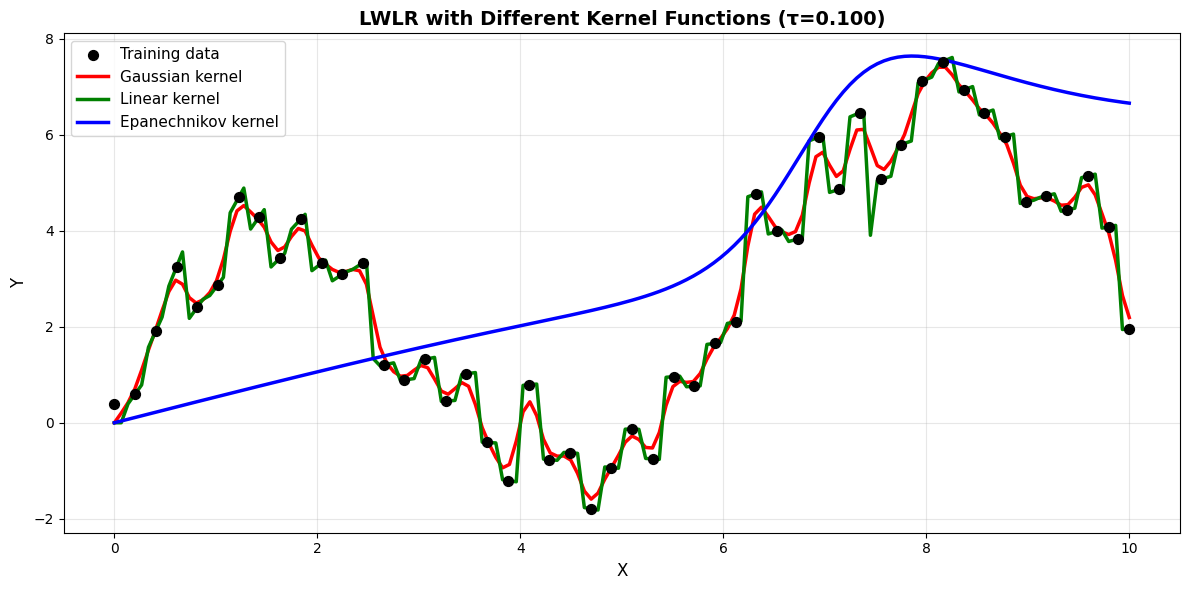

Kernel comparison complete!


In [5]:
# Use the optimal bandwidth found above
tau_opt = optimal_tau

# Generate smooth query points
X_query = np.linspace(0, 10, 150).reshape(-1, 1)

# Fit models with different kernels
models = {
    'Gaussian': LocallyWeightedLinearRegression(tau=tau_opt, kernel='gaussian'),
    'Linear': LocallyWeightedLinearRegression(tau=tau_opt, kernel='linear'),
    'Epanechnikov': LocallyWeightedLinearRegression(tau=tau_opt, kernel='epanechnikov')
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_query)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(X_train, y_train, color='black', s=50, label='Training data', zorder=3)

colors = {'Gaussian': 'red', 'Linear': 'green', 'Epanechnikov': 'blue'}
for name, pred in predictions.items():
    ax.plot(X_query, pred, linewidth=2.5, color=colors[name], label=f'{name} kernel')

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'LWLR with Different Kernel Functions (τ={tau_opt:.3f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Kernel comparison complete!")

## Section 7: 2D Example - Surface Fitting

LWLR also works with multi-dimensional features. Let's create a 2D example.

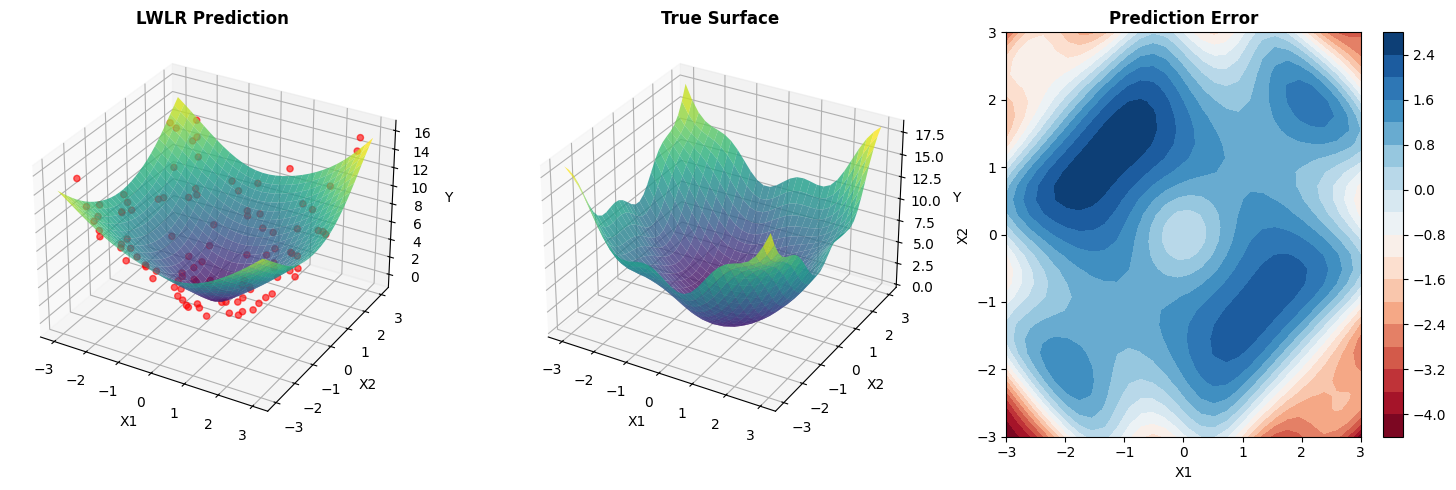


2D LWLR Performance:
MSE: 2.1100
RMSE: 1.4526
Mean prediction: 6.9705
Mean true value: 6.4138


In [6]:
# Generate 2D non-linear synthetic data
np.random.seed(42)
n_samples = 100
X1_2d = np.random.uniform(-3, 3, n_samples)
X2_2d = np.random.uniform(-3, 3, n_samples)
X_2d = np.column_stack([X1_2d, X2_2d])

# Non-linear function: z = x^2 + y^2 + sin(x*y)
y_2d = X1_2d**2 + X2_2d**2 + np.sin(X1_2d * X2_2d) + np.random.randn(n_samples) * 0.3

# Create query grid
x_range = np.linspace(-3, 3, 30)
y_range = np.linspace(-3, 3, 30)
X_grid, Y_grid = np.meshgrid(x_range, y_range)
X_query_2d = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# Fit LWLR
model_2d = LocallyWeightedLinearRegression(tau=1.0, kernel='gaussian')
model_2d.fit(X_2d, y_2d)
y_pred_2d = model_2d.predict(X_query_2d)
Z_pred = y_pred_2d.reshape(X_grid.shape)

# True surface
Z_true = X_grid**2 + Y_grid**2 + np.sin(X_grid * Y_grid)

# Plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 5))

# Plot 1: LWLR prediction
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_pred, cmap='viridis', alpha=0.8)
ax1.scatter(X1_2d, X2_2d, y_2d, color='red', s=20, alpha=0.6)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Y')
ax1.set_title('LWLR Prediction', fontweight='bold')

# Plot 2: True surface
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_true, cmap='viridis', alpha=0.8)
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('Y')
ax2.set_title('True Surface', fontweight='bold')

# Plot 3: Prediction error
ax3 = fig.add_subplot(133)
error = Z_pred - Z_true
im = ax3.contourf(X_grid, Y_grid, error, levels=20, cmap='RdBu')
ax3.set_xlabel('X1')
ax3.set_ylabel('X2')
ax3.set_title('Prediction Error', fontweight='bold')
plt.colorbar(im, ax=ax3)

plt.tight_layout()
plt.show()

# Print error metrics
mse_2d = np.mean(error**2)
rmse_2d = np.sqrt(mse_2d)
print(f"\n2D LWLR Performance:")
print(f"MSE: {mse_2d:.4f}")
print(f"RMSE: {rmse_2d:.4f}")
print(f"Mean prediction: {y_pred_2d.mean():.4f}")
print(f"Mean true value: {Z_true.mean():.4f}")

## Section 8: LWLR vs Linear Regression Comparison

When does LWLR outperform global linear regression?

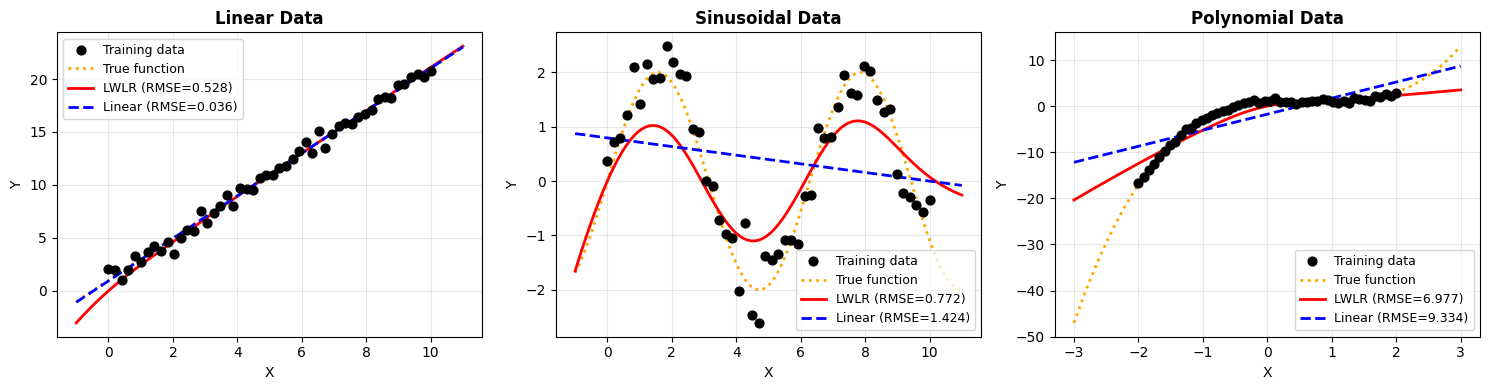

LWLR vs Linear Regression comparison complete!


In [7]:
# Create multiple test cases
test_cases = [
    {
        'name': 'Linear Data',
        'X': np.linspace(0, 10, 50).reshape(-1, 1),
        'y_func': lambda x: 2 * x + 1,
        'noise': 0.5
    },
    {
        'name': 'Sinusoidal Data',
        'X': np.linspace(0, 10, 50).reshape(-1, 1),
        'y_func': lambda x: 2 * np.sin(x),
        'noise': 0.5
    },
    {
        'name': 'Polynomial Data',
        'X': np.linspace(-2, 2, 50).reshape(-1, 1),
        'y_func': lambda x: x**3 - 2*x**2 + x + 1,
        'noise': 0.3
    }
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, case in enumerate(test_cases):
    ax = axes[idx]
    
    # Generate data
    X_train = case['X']
    y_true = case['y_func'](X_train.ravel())
    y_train = y_true + np.random.randn(len(y_true)) * case['noise']
    
    # Query points
    X_query = np.linspace(X_train.min() - 1, X_train.max() + 1, 100).reshape(-1, 1)
    y_true_query = case['y_func'](X_query.ravel())
    
    # LWLR
    lwlr_model = LocallyWeightedLinearRegression(tau=1.0, kernel='gaussian')
    lwlr_model.fit(X_train, y_train)
    y_lwlr = lwlr_model.predict(X_query)
    lwlr_error = np.sqrt(np.mean((y_lwlr - y_true_query)**2))
    
    # Linear Regression
    coeffs = np.polyfit(X_train.ravel(), y_train, 1)
    y_linear = np.polyval(coeffs, X_query.ravel())
    linear_error = np.sqrt(np.mean((y_linear - y_true_query)**2))
    
    # Plot
    ax.scatter(X_train, y_train, color='black', s=40, label='Training data', zorder=3)
    ax.plot(X_query, y_true_query, 'orange', linewidth=2, linestyle=':', label='True function')
    ax.plot(X_query, y_lwlr, 'r-', linewidth=2, label=f'LWLR (RMSE={lwlr_error:.3f})')
    ax.plot(X_query, y_linear, 'b--', linewidth=2, label=f'Linear (RMSE={linear_error:.3f})')
    
    ax.set_title(case['name'], fontweight='bold', fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("LWLR vs Linear Regression comparison complete!")

## Section 9: Computational Complexity Analysis

Let's analyze and benchmark the computational cost of LWLR.

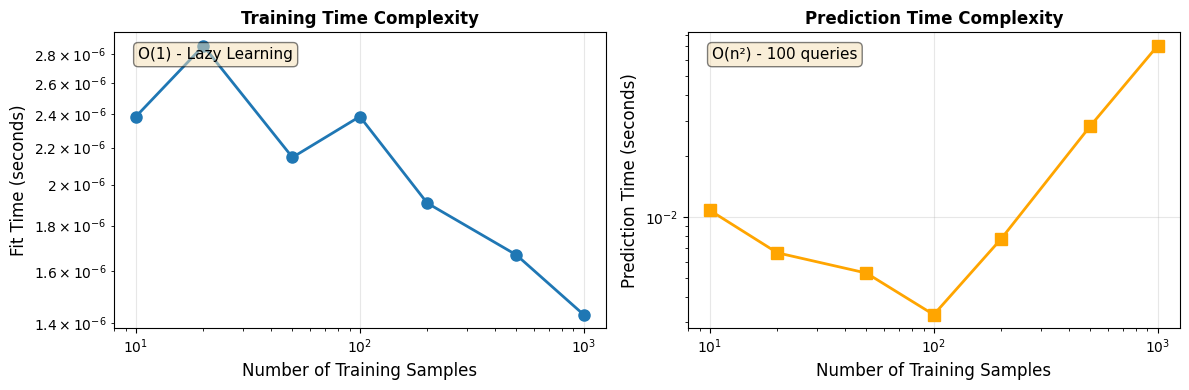


Computational Complexity Analysis:
n_samples  fit_time (s)    predict_time (s)    
---------------------------------------------
10         0.000002        0.010766            
20         0.000003        0.006633            
50         0.000002        0.005262            
100        0.000002        0.003272            
200        0.000002        0.007775            
500        0.000002        0.028178            
1000       0.000001        0.070492            


In [8]:
# Timing analysis
sample_sizes = [10, 20, 50, 100, 200, 500, 1000]
query_sizes = [100, 100, 100, 100, 100, 100, 100]
fit_times = []
predict_times = []

for n_samples, n_queries in zip(sample_sizes, query_sizes):
    # Generate data
    X_train = np.random.randn(n_samples, 5)
    y_train = np.random.randn(n_samples)
    X_query = np.random.randn(n_queries, 5)
    
    # LWLR fit time
    model = LocallyWeightedLinearRegression(tau=1.0, kernel='gaussian')
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    fit_times.append(fit_time)
    
    # LWLR predict time
    start = time.time()
    y_pred = model.predict(X_query)
    predict_time = time.time() - start
    predict_times.append(predict_time)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Fit time
ax1.loglog(sample_sizes, fit_times, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Training Samples', fontsize=12)
ax1.set_ylabel('Fit Time (seconds)', fontsize=12)
ax1.set_title('Training Time Complexity', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, 'O(1) - Lazy Learning', transform=ax1.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Predict time
ax2.loglog(sample_sizes, predict_times, 's-', linewidth=2, markersize=8, color='orange')
ax2.set_xlabel('Number of Training Samples', fontsize=12)
ax2.set_ylabel('Prediction Time (seconds)', fontsize=12)
ax2.set_title('Prediction Time Complexity', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, 'O(n²) - 100 queries', transform=ax2.transAxes,
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nComputational Complexity Analysis:")
print(f"{'n_samples':<10} {'fit_time (s)':<15} {'predict_time (s)':<20}")
print("-" * 45)
for n, ft, pt in zip(sample_sizes, fit_times, predict_times):
    print(f"{n:<10} {ft:<15.6f} {pt:<20.6f}")

## Section 10: Library Function - statsmodels LOWESS

The `statsmodels` library provides LOWESS (Locally Weighted Scatterplot Smoothing), which is a variant of LWLR.

In [9]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Generate test data
np.random.seed(42)
X_test = np.linspace(0, 10, 100)
y_test = 2 * np.sin(X_test) + np.random.randn(100) * 0.5

# statsmodels LOWESS
# frac: fraction of data to use in each local regression (default 2/3)
result = lowess(y_test, X_test, frac=0.3)

# Our LWLR implementation
X_train = X_test.reshape(-1, 1)
model = LocallyWeightedLinearRegression(tau=0.8, kernel='gaussian')
model.fit(X_train, y_test)
X_query = np.linspace(0, 10, 100).reshape(-1, 1)
y_pred_our = model.predict(X_query)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(X_test, y_test, color='black', s=30, alpha=0.6, label='Data', zorder=2)
ax.plot(result[:, 0], result[:, 1], 'r-', linewidth=2.5, label='statsmodels LOWESS')
ax.plot(X_query, y_pred_our, 'b--', linewidth=2.5, label='Our LWLR Implementation')

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('LWLR vs statsmodels LOWESS', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("statsmodels LOWESS library function comparison complete!")

ModuleNotFoundError: No module named 'statsmodels'

## Section 11: Advantages and Disadvantages

| Aspect | LWLR | Global Linear Regression | LWLR vs Others |
|--------|------|--------------------------|----------------|
| **Fitting** | O(1) - Lazy learning | O(n) - Explicit training | LWLR faster to train |
| **Prediction** | O(n²) per query | O(1) per query | Linear much faster |
| **Memory** | O(n) - Store all data | O(d) - Store parameters only | LWLR uses more memory |
| **Non-linearity** | ✓ Can fit non-linear | ✗ Only global linear | LWLR much more flexible |
| **Data requirements** | Small to medium datasets | Any size | Both scalable |
| **Interpretability** | ✗ No global model | ✓ Simple parameters | Linear more interpretable |
| **Noise robustness** | ✓ Local weighting helps | ✓ Averaging helps | Similar robustness |
| **Outlier sensitivity** | Medium - affects local region | High - affects global model | Linear more affected |
| **Extrapolation** | ✗ Poor (no data) | ✓ Can extrapolate | Linear better outside range |
| **Computational stability** | ✓ Multiple local fits | ✓ Single global fit | Both stable |

### Advantages of LWLR:
1. **Flexibility**: Can model non-linear relationships without explicit parametric form
2. **Local adaptation**: Different slope in different regions of feature space
3. **No training required**: Lazy learning - just store data
4. **Robustness**: Weighted approach reduces influence of distant/outlier points
5. **Interpretability**: Local linear model is simple and interpretable

### Disadvantages of LWLR:
1. **Slow prediction**: O(n²) for m queries (must solve weighted LS for each query)
2. **Memory intensive**: Must store entire training dataset
3. **Curse of dimensionality**: Distance becomes less meaningful in high dimensions
4. **Bandwidth selection**: Requires tuning via cross-validation
5. **No extrapolation**: Can't reliably predict outside data range
6. **No global model**: Can't interpret the overall relationship

## Section 12: When to Use LWLR - Decision Guide

### Use LWLR when:
✓ Relationship between variables is **non-linear but smooth**
✓ You have a **small to medium-sized dataset** (< 10,000 samples)
✓ **Real-time prediction not critical** (can tolerate O(n²) cost)
✓ Want to **explore data patterns** without committing to parametric form
✓ Need **local robustness** to outliers in specific regions
✓ Have **low-dimensional features** (< 20 dimensions)

### Avoid LWLR when:
✗ Dataset is **very large** (> 100,000 samples)
✗ Need **real-time predictions** at scale
✗ Require **interpretable global model**
✗ Features are **high-dimensional** (curse of dimensionality)
✗ Need to **extrapolate** beyond data range
✗ Relationship is **truly linear** (use simpler linear regression)
✗ Need **uncertainty quantification** (confidence intervals)

### Comparison with Alternatives:

| Method | When to Use | Advantages | Disadvantages |
|--------|-------------|-----------|---------------|
| **Linear Regression** | Linear relationships | Fast, interpretable, extrapolates | Inflexible, may underfit |
| **LWLR** | Non-linear, small data | Flexible, local adaptation | Slow, memory-intensive |
| **Polynomial Regression** | Non-linear, explicit form | Flexible, parametric | Need to choose degree |
| **Splines** | Non-linear, smooth | Very flexible, smooth | Complex tuning |
| **Neural Networks** | Complex non-linear | Very flexible, scalable | Black box, requires large data |
| **Random Forests** | Mixed relationships | Flexible, handles many features | Non-smooth predictions |
| **Gaussian Process** | Uncertainty important | Provides confidence intervals | O(n³) complexity |

### Practical Recommendations:

1. **Start with linear regression** - establish baseline
2. **Try LWLR if**:
   - Linear fit poor AND
   - Dataset not huge AND
   - Prediction speed not critical
3. **For large datasets**: Use splines or neural networks instead
4. **For uncertainty**: Use Gaussian Process regression
5. **For interpretability**: Stick with linear or polynomial regression
6. **For exploration**: LWLR excellent for initial data analysis

## Section 13: Summary and Key Takeaways

### Key Formulas

**Weight function (Gaussian kernel)**:
$$w_i = \exp\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$$

**Weighted least squares solution**:
$$\theta^* = (X^T W X)^{-1} X^T W y$$

**Prediction**:
$$\hat{y}^* = (\theta^*)^T x^*$$

### Algorithm Steps
1. For query point $x^*$, compute weights $w_i$ to all training points
2. Form diagonal weight matrix $W$
3. Solve weighted LS problem to get $\theta^*$
4. Predict using $\hat{y}^* = (\theta^*)^T x^*$

### Complexity
- **Training**: O(1) - just store data
- **Prediction**: O(n²) - solve new LS problem for each query
- **Memory**: O(n) - must store all training data

### Bandwidth Selection
- Use **cross-validation** to select optimal $\tau$
- Small $\tau$ → overfitting (wiggly fit)
- Large $\tau$ → underfitting (too smooth, similar to global fit)
- Sweet spot typically found empirically

### LWLR Strengths
✓ Non-parametric - no assumptions on functional form
✓ Flexible - can model complex non-linear patterns
✓ Local adaptation - different behavior in different regions
✓ Robust weighting - reduces influence of distant outliers
✓ Easy to understand - weighted local regression

### LWLR Limitations
✗ Expensive prediction - O(n²) per query
✗ Memory intensive - must keep all data
✗ Curse of dimensionality - distances poorly defined in high dimensions
✗ No extrapolation - undefined behavior outside data range
✗ Bandwidth tuning - requires cross-validation

### Practice Tips
1. Always **normalize features** to same scale before using distance
2. Use **cross-validation** for bandwidth selection
3. Consider **dimensionality reduction** if > 10 features
4. For **real-time prediction**: precompute results or use approximations
5. **Compare with alternatives** (splines, polynomial, neural networks)

## References and Further Reading

### Papers
1. **Cleveland, W. S. (1979)**. "Robust locally weighted regression and smoothing scatterplots." *Journal of the American Statistical Association*, 74(368), 829-836.
   - Original LOESS paper - foundational

2. **Wand, M. P., & Jones, M. C. (1995)**. *Kernel Smoothing.* Chapman and Hall.
   - Comprehensive treatment of kernel methods including LWLR

### Books
1. **Hastie, T., Tibshirani, R., & Friedman, J. (2009)**. *The Elements of Statistical Learning*. Springer.
   - Chapters on local regression and smoothing

2. **Wand, M. P., & Jones, M. C. (1995)**. *Kernel Smoothing.* Chapman and Hall.

### Online Resources
- **statsmodels LOWESS documentation**: https://www.statsmodels.org/stable/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html
- **scikit-learn neighbors**: https://scikit-learn.org/stable/modules/neighbors.html

### Related Topics
- **Kernel Methods**: General framework that includes LWLR
- **Smoothing Splines**: Alternative non-parametric regression
- **Gaussian Processes**: Probabilistic approach to local regression
- **KNN Regression**: Similar idea but uses discrete neighbors instead of weights

---
## Practice Exercises

**Conceptual**

1. LWLR assigns weight $w_i = \exp\!\left(-\frac{(x_i - x)^2}{2\tau^2}\right)$ to each training point when predicting at query point $x$. What happens to the model as $\tau \to 0$? As $\tau \to \infty$? Sketch the effective model in each extreme.

2. LWLR is called a **non-parametric** method. What does this mean in terms of how many parameters grow with the dataset size? How does this contrast with ordinary linear regression?

3. LWLR solves a separate weighted least-squares problem for every query point $x$. Describe the computational cost of making a single prediction when there are $n$ training points and $p$ features.

4. Explain why LWLR cannot simply "memorize" weights $\theta$ at training time and apply them later. Why must the full training set be retained?

5. A kernel in LWLR controls "locality." The Gaussian kernel $w_i = \exp(-\|x_i - x\|^2 / 2\tau^2)$ is the most common choice. Name one alternative kernel and describe the shape of its weight function.

**Numerical**

6. Generate 200 points from $y = \sin(x) + \epsilon$, $x \in [-3, 3]$, $\epsilon \sim \mathcal{N}(0, 0.1)$. Fit LWLR with $\tau \in \{0.05, 0.2, 1.0, 5.0\}$. On a single plot, show the fitted curve for each $\tau$ alongside the true sine function. Which $\tau$ best balances bias and variance?

7. Implement LWLR from scratch using only NumPy. For each query point in a test grid, solve the weighted normal equation $\theta(x) = (X^T W X)^{-1} X^T W y$ where $W = \text{diag}(w_1, \ldots, w_n)$. Verify your implementation matches the plot from Exercise 6.

8. Demonstrate the bias-variance trade-off numerically: for each of 20 random train/test splits, record the test MSE for LWLR with $\tau \in \{0.05, 0.5, 5.0\}$. Plot the mean ± 1 std of test MSE vs $\tau$ to show the U-shaped curve.

**Reflection**

9. Suppose you have $n = 10^6$ training points and need real-time predictions (< 1ms latency). Would you choose LWLR or ordinary linear regression? What approach could let you keep LWLR's flexibility at scale (hint: think approximate nearest neighbors or kernel approximations)?